# RANSAC vs polyfit — I-z Barrier Height Comparison

Compares `method='polyfit'` (default) vs `method='RANSAC'` for `iz.barrier_height`.

## 1. Setup

In [1]:
import nanonis_reader as nr
from nanonis_reader.cmap_custom import bwr
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 7
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [86.0/25.4, 86.0/25.4]

## 2. File Paths

In [2]:
DAT_IZ_PATH  = "/Users/kim/Library/CloudStorage/OneDrive-Personal/Data/230922_TNS_STM6/TNS_STM6_#117_4962.dat"
GRID_IZ_PATH = "/Users/kim/Library/CloudStorage/OneDrive-Personal/Data/230922_TNS_STM6/TNS_STM6_#117_3533.3ds"

---
## 3. .dat — Single I-z Spectrum

`iz.barrier_height()`: ln(I) vs Z linear fitting → apparent barrier height (eV)

In [3]:
d_iz = nr.load(DAT_IZ_PATH)
z, I = d_iz.iz.raw()

# polyfit
bh_p, err_p, slope_p = d_iz.iz.barrier_height()
# RANSAC
bh_r, err_r, slope_r = d_iz.iz.barrier_height(method='RANSAC')

print(f'polyfit: BH = {bh_p:.3f} ± {err_p:.4f} eV,  slope = {slope_p:.2e} m⁻¹')
print(f'RANSAC:  BH = {bh_r:.3f} ± {err_r:.4f} eV,  slope = {slope_r:.2e} m⁻¹')
print(f'Δ(BH)  = {abs(bh_p - bh_r):.4f} eV')

polyfit: BH = 4.705 ± 0.0696 eV,  slope = -2.22e+10 m⁻¹
RANSAC:  BH = 4.705 ± 0.0696 eV,  slope = -2.22e+10 m⁻¹
Δ(BH)  = 0.0000 eV


### 3.1 ln(I) vs Z — Fitting Visualization

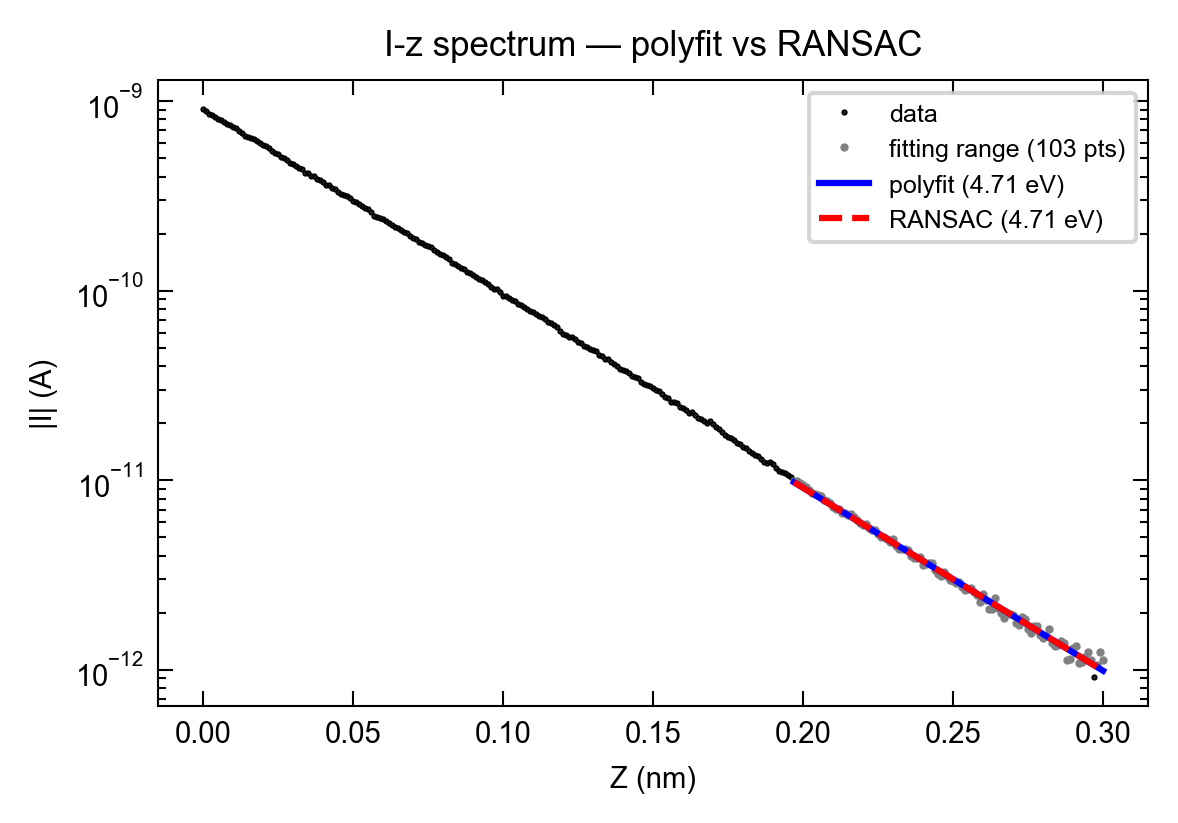

In [4]:
z, I = d_iz.iz.raw()
I_abs = np.abs(I)
log_I = np.log(I_abs)

# Fitting range
fit_range = (1e-12, 10e-12)
idx = np.where((fit_range[0] <= I_abs) & (I_abs <= fit_range[1]))[0]

# Refit to get actual intercepts
slope_p_fit, intercept_p = np.polyfit(z[idx], log_I[idx], 1)

from sklearn.linear_model import RANSACRegressor, LinearRegression
ransac = RANSACRegressor(estimator=LinearRegression())
ransac.fit(z[idx].reshape(-1,1), log_I[idx])
slope_r_fit = ransac.estimator_.coef_[0]
intercept_r = ransac.estimator_.intercept_

fig, ax = plt.subplots(figsize=(100/25.4, 70/25.4))
ax.semilogy(z * 1e9, I_abs, 'k.', ms=1, label='data')

# Highlight fitting range
ax.semilogy(z[idx] * 1e9, I_abs[idx], '.', color='gray', ms=2, label=f'fitting range ({len(idx)} pts)')

# Fitted lines — extended to full data range
z_line = np.linspace(z.min(), z.max(), 200)
ax.semilogy(z_line * 1e9, np.exp(slope_p_fit * z_line + intercept_p),
            'b-', lw=1.5, label=f'polyfit ({bh_p:.2f} eV)')
ax.semilogy(z_line * 1e9, np.exp(slope_r_fit * z_line + intercept_r),
            'r--', lw=1.5, label=f'RANSAC ({bh_r:.2f} eV)')

ax.set_xlabel('Z (nm)')
ax.set_ylabel('|I| (A)')
ax.set_title('I-z spectrum — polyfit vs RANSAC')
ax.legend(fontsize=6)
fig.tight_layout()

---
## 4. .3ds — Grid I-z Barrier Height Map

In [5]:
d_grid = nr.load(GRID_IZ_PATH)
print(f'File: {d_grid.fname}')
print(f'Grid size: {d_grid.header["dim_px"]}')

File: TNS_STM6_#117_3533.3ds
Grid size: [50, 50]


### 4.1 Single pixel comparison

In [6]:
line, pixel = 0, 0

bh_p = d_grid.iz.barrier_height_at(line, pixel, method='polyfit')
bh_r = d_grid.iz.barrier_height_at(line, pixel, method='RANSAC')
print(f'Pixel ({line}, {pixel}):')
print(f'  polyfit: {bh_p:.3f} eV')
print(f'  RANSAC:  {bh_r:.3f} eV')
print(f'  Δ = {abs(bh_p - bh_r):.4f} eV')

# Plot I-z at this pixel with fitting lines
z_grid = d_grid.iz.sweep_signal
_, I_3d = d_grid.iz.raw()
I_pix = np.abs(I_3d[line, pixel])
log_I_pix = np.log(I_pix)

fit_range = (1e-12, 10e-12)
idx = np.where((fit_range[0] <= I_pix) & (I_pix <= fit_range[1]))[0]

if len(idx) > 1:
    slope_gp, intercept_gp = np.polyfit(z_grid[idx], log_I_pix[idx], 1)
    ransac_g = RANSACRegressor(estimator=LinearRegression())
    ransac_g.fit(z_grid[idx].reshape(-1,1), log_I_pix[idx])
    slope_gr = ransac_g.estimator_.coef_[0]
    intercept_gr = ransac_g.estimator_.intercept_

    fig, ax = plt.subplots(figsize=(100/25.4, 70/25.4))
    ax.semilogy(z_grid * 1e9, I_pix, 'k.', ms=2, label='data')
    ax.semilogy(z_grid[idx] * 1e9, I_pix[idx], '.', color='gray', ms=3, label=f'fitting range ({len(idx)} pts)')

    z_line = np.linspace(z_grid.min(), z_grid.max(), 200)
    ax.semilogy(z_line * 1e9, np.exp(slope_gp * z_line + intercept_gp),
                'b-', lw=1.5, label=f'polyfit ({bh_p:.2f} eV)')
    ax.semilogy(z_line * 1e9, np.exp(slope_gr * z_line + intercept_gr),
                'r--', lw=1.5, label=f'RANSAC ({bh_r:.2f} eV)')

    ax.set_xlabel('Z (nm)')
    ax.set_ylabel('|I| (A)')
    ax.set_title(f'Grid I-z at ({line},{pixel}) — polyfit vs RANSAC')
    ax.legend(fontsize=6)
    fig.tight_layout()
else:
    print('Not enough points in fitting range')

Pixel (0, 0):
  polyfit: 4.583 eV
  RANSAC:  4.583 eV
  Δ = 0.0000 eV


### 4.2 Full barrier height map — polyfit vs RANSAC

In [7]:
# This may take a while (~1-2 min for 50x50)
import time

t0 = time.time()
bh_map_p = d_grid.iz.barrier_height(method='polyfit')
t_poly = time.time() - t0

t0 = time.time()
bh_map_r = d_grid.iz.barrier_height(method='RANSAC')
t_ransac = time.time() - t0

print(f'polyfit: {t_poly:.1f}s,  RANSAC: {t_ransac:.1f}s')

polyfit: 0.0s,  RANSAC: 1.9s


max|Δ| = 1.0511 eV


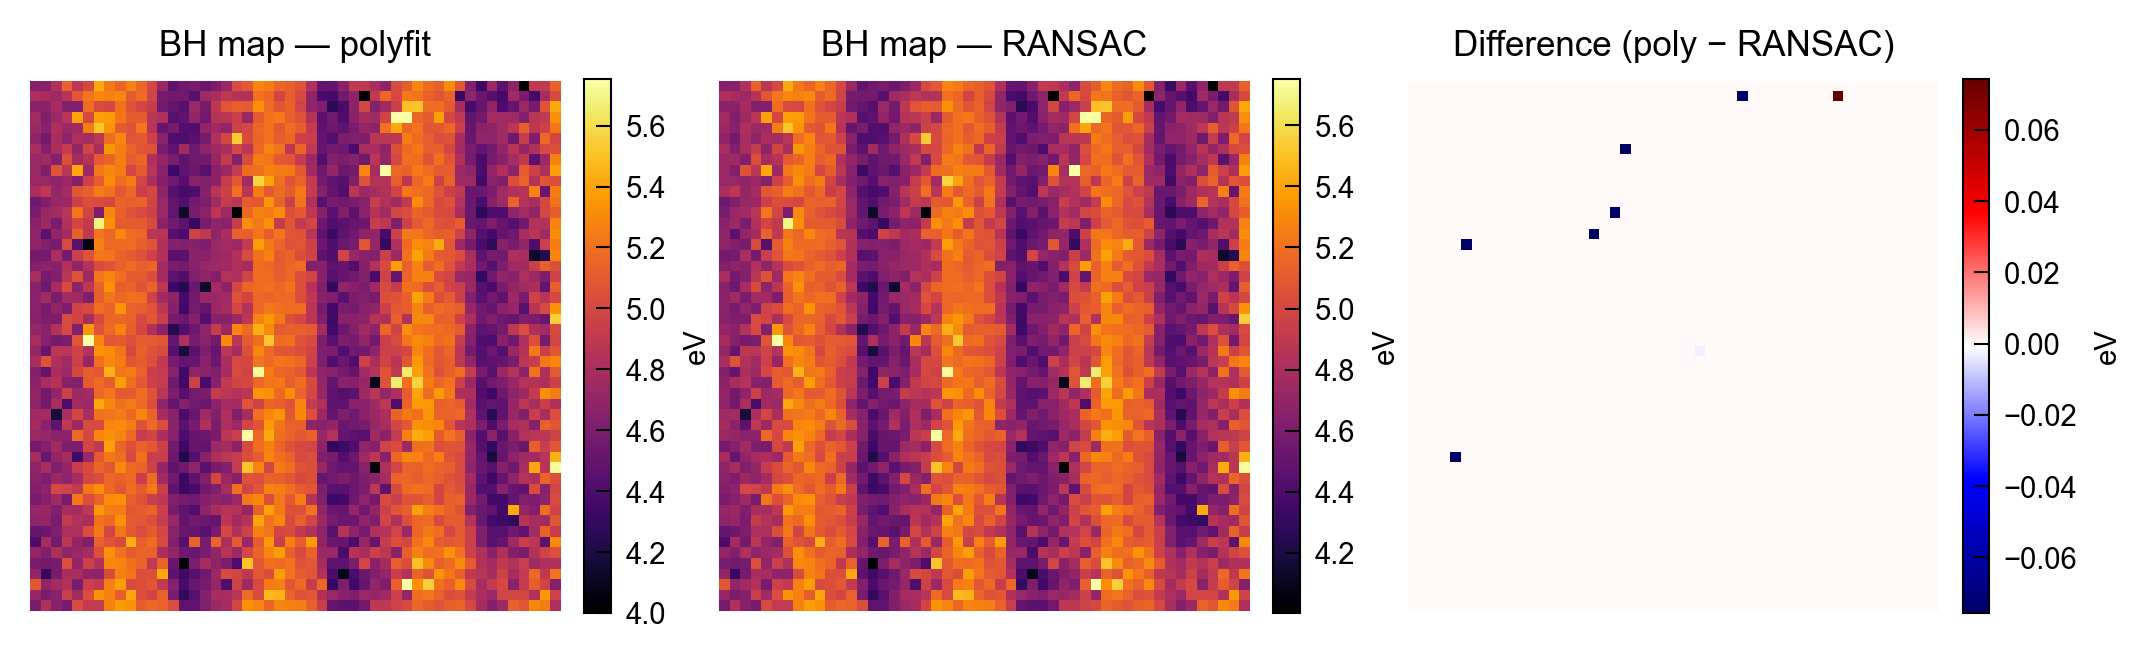

In [8]:
diff = bh_map_p - bh_map_r

fig, axs = plt.subplots(1, 3, figsize=(180/25.4, 55/25.4))

for ax, img, label in zip(axs[:2], [bh_map_p, bh_map_r], ['polyfit', 'RANSAC']):
    mu, sig = np.nanmean(img), np.nanstd(img)
    im = ax.imshow(img, cmap='inferno', origin='lower',
                   vmin=max(0, mu-3*sig), vmax=mu+3*sig)
    ax.set_title(f'BH map — {label}')
    ax.set_axis_off()
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='eV')

mu_d, sig_d = np.nanmean(diff), np.nanstd(diff)
im = axs[2].imshow(diff, cmap=bwr(), origin='lower',
                    vmin=mu_d-3*sig_d, vmax=mu_d+3*sig_d)
axs[2].set_title('Difference (poly − RANSAC)')
axs[2].set_axis_off()
plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04, label='eV')

fig.tight_layout(pad=0.3)
print(f'max|Δ| = {np.nanmax(np.abs(diff)):.4f} eV')

### 4.3 Barrier height distribution

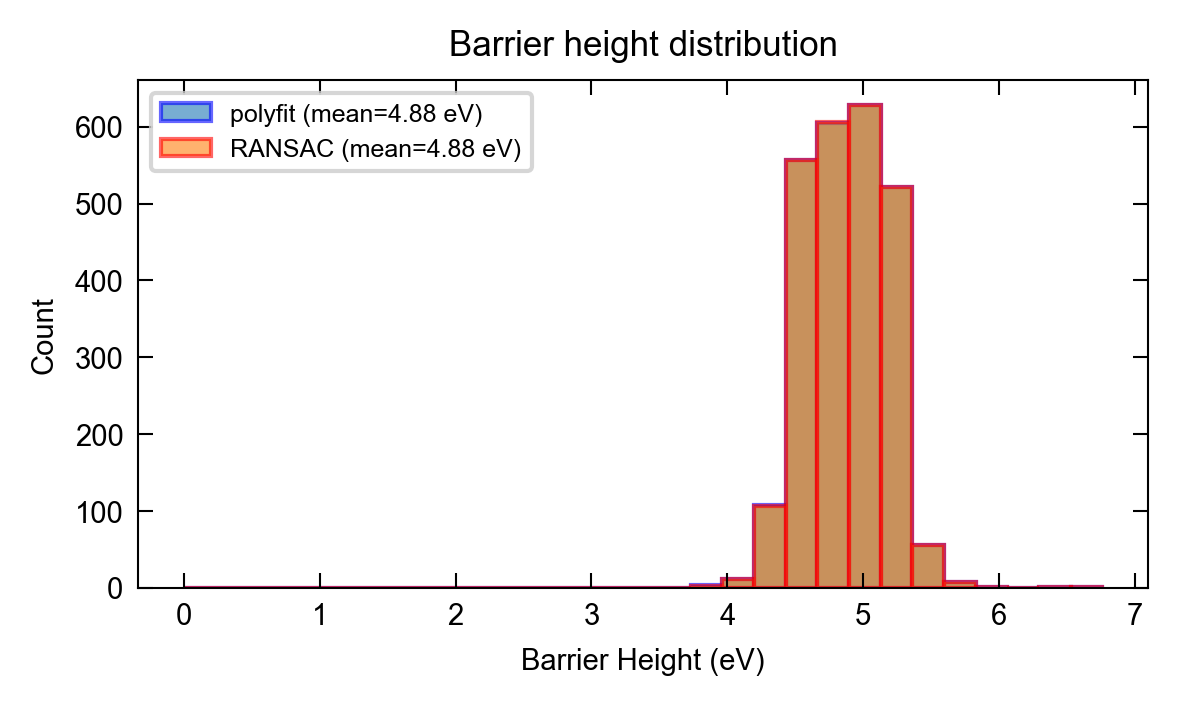

In [9]:
fig, ax = plt.subplots(figsize=(100/25.4, 60/25.4))

valid_p = bh_map_p[~np.isnan(bh_map_p)].flatten()
valid_r = bh_map_r[~np.isnan(bh_map_r)].flatten()

bins = np.linspace(0, max(valid_p.max(), valid_r.max()), 30)
ax.hist(valid_p, bins=bins, alpha=0.6, label=f'polyfit (mean={valid_p.mean():.2f} eV)', edgecolor='blue')
ax.hist(valid_r, bins=bins, alpha=0.6, label=f'RANSAC (mean={valid_r.mean():.2f} eV)', edgecolor='red')
ax.set_xlabel('Barrier Height (eV)')
ax.set_ylabel('Count')
ax.legend(fontsize=6)
ax.set_title('Barrier height distribution')
fig.tight_layout()